## Setup and Installation

In [1]:
!pip install tensorflow scikit-learn datasets matplotlib -q

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from datasets import load_dataset, concatenate_datasets
import matplotlib.pyplot as plt
import time

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data Loading and Preprocessing

In [3]:
# Load IMDB dataset
print("Loading IMDB dataset...")
train_raw = load_dataset("imdb", split="train")
test_raw = load_dataset("imdb", split="test")

print(f"Train size: {len(train_raw)}")
print(f"Test size: {len(test_raw)}")

Loading IMDB dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train size: 25000
Test size: 25000


In [4]:
# Create balanced dataset (5000 train, 2000 test per class)
def create_balanced_dataset(dataset, samples_per_class):
    neg = dataset.filter(lambda x: x["label"] == 0).shuffle(seed=42).select(range(samples_per_class))
    pos = dataset.filter(lambda x: x["label"] == 1).shuffle(seed=42).select(range(samples_per_class))
    return concatenate_datasets([neg, pos]).shuffle(seed=42)

train_ds = create_balanced_dataset(train_raw, 5000)
test_ds = create_balanced_dataset(test_raw, 2000)

# Convert to lists
X_train = list(train_ds["text"])
y_train = [int(x) for x in train_ds["label"]]
X_test = list(test_ds["text"])
y_test = [int(x) for x in test_ds["label"]]

print(f"\nBalanced dataset:")
print(f"Train: {len(X_train)} samples")
print(f"Test: {len(X_test)} samples")
print(f"Train class distribution: {np.bincount(y_train)}")
print(f"Test class distribution: {np.bincount(y_test)}")

Filter:   0%|          | 0/25000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/25000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/25000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/25000 [00:00<?, ? examples/s]


Balanced dataset:
Train: 10000 samples
Test: 4000 samples
Train class distribution: [5000 5000]
Test class distribution: [2000 2000]


In [5]:
# Sample reviews
print("Sample positive review:")
print("=" * 80)
pos_idx = y_train.index(1)
print(X_train[pos_idx][:300] + "...")

print("\nSample negative review:")
print("=" * 80)
neg_idx = y_train.index(0)
print(X_train[neg_idx][:300] + "...")

Sample positive review:
First, this is a review of the two disc set that came together with the "Wonderland" DVD rental.<br /><br />The two movies included with the rental, "Wonderland" and the Johnny Wadd documentary, totally obliterate the myth created by "Boogie Nights". That myth being that the characters involved in t...

Sample negative review:
Well I too had heard read all the breathless reviews and comments about how this movie might deserve the Best Picture Oscar so I went to see it today. What a major disappointment! 1) If you read the other reviews you will learn from members of the U.S. military who served in Iraq how unlikely the ev...


## Approach 1: TF-IDF + Logistic Regression

In [6]:
# TF-IDF vectorization
print("Training TF-IDF vectorizer...")
start_time = time.time()

tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.8,
    stop_words='english'
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

tfidf_time = time.time() - start_time

print(f"\nTF-IDF vectorization time: {tfidf_time:.2f} seconds")
print(f"Train matrix shape: {X_train_tfidf.shape}")
print(f"Test matrix shape: {X_test_tfidf.shape}")
print(f"Vocabulary size: {len(tfidf_vectorizer.vocabulary_)}")

Training TF-IDF vectorizer...

TF-IDF vectorization time: 5.76 seconds
Train matrix shape: (10000, 10000)
Test matrix shape: (4000, 10000)
Vocabulary size: 10000


In [7]:
# Display top TF-IDF features
feature_names = tfidf_vectorizer.get_feature_names_out()
print("\nSample features (unigrams and bigrams):")
print(feature_names[:20])
print("...")
print(feature_names[-20:])


Sample features (unigrams and bigrams):
['00' '000' '10' '10 10' '10 br' '10 minutes' '10 stars' '10 year'
 '10 years' '100' '1000' '11' '12' '12 year' '12 years' '13' '13th' '14'
 '14 year' '15']
...
['young boy' 'young girl' 'young girls' 'young man' 'young people'
 'young woman' 'young women' 'younger' 'younger brother' 'youngest'
 'youth' 'youthful' 'youtube' 'zero' 'zero day' 'zodiac' 'zombie'
 'zombies' 'zone' 'zorro']


In [8]:
# Train Logistic Regression
print("Training Logistic Regression model...")
start_time = time.time()

lr_model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver='liblinear',
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

lr_train_time = time.time() - start_time
print(f"Training time: {lr_train_time:.2f} seconds")

Training Logistic Regression model...
Training time: 0.13 seconds


In [9]:
# Evaluate TF-IDF + LR model
print("Evaluating TF-IDF + Logistic Regression...\n")

start_time = time.time()
y_pred_lr = lr_model.predict(X_test_tfidf)
lr_pred_time = time.time() - start_time

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print("Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Negative', 'Positive']))

print(f"\nAccuracy: {lr_accuracy:.4f}")
print(f"F1 Score: {lr_f1:.4f}")
print(f"Prediction time: {lr_pred_time:.2f} seconds")

Evaluating TF-IDF + Logistic Regression...

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.86      0.87      2000
    Positive       0.87      0.88      0.87      2000

    accuracy                           0.87      4000
   macro avg       0.87      0.87      0.87      4000
weighted avg       0.87      0.87      0.87      4000


Accuracy: 0.8720
F1 Score: 0.8729
Prediction time: 0.00 seconds


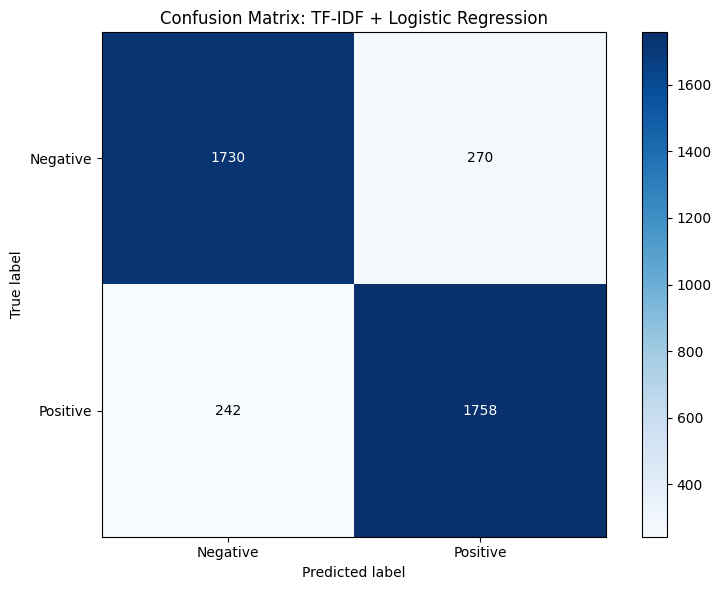

In [10]:
# Confusion Matrix for LR
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(8, 6))
plt.imshow(cm_lr, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix: TF-IDF + Logistic Regression')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Negative', 'Positive'])
plt.yticks(tick_marks, ['Negative', 'Positive'])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_lr[i, j],
                ha="center", va="center",
                color="white" if cm_lr[i, j] > cm_lr.max() / 2 else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

In [11]:
# Top predictive features
feature_importance = lr_model.coef_[0]
top_positive_idx = np.argsort(feature_importance)[-15:]
top_negative_idx = np.argsort(feature_importance)[:15]

print("Top 15 features predicting POSITIVE sentiment:")
for idx in reversed(top_positive_idx):
    print(f"  {feature_names[idx]:25s} (coef: {feature_importance[idx]:.4f})")

print("\nTop 15 features predicting NEGATIVE sentiment:")
for idx in top_negative_idx:
    print(f"  {feature_names[idx]:25s} (coef: {feature_importance[idx]:.4f})")

Top 15 features predicting POSITIVE sentiment:
  great                     (coef: 5.3795)
  excellent                 (coef: 4.2066)
  best                      (coef: 4.1894)
  wonderful                 (coef: 3.7924)
  perfect                   (coef: 3.3673)
  fun                       (coef: 2.9083)
  enjoyed                   (coef: 2.7451)
  today                     (coef: 2.7328)
  amazing                   (coef: 2.7280)
  love                      (coef: 2.6790)
  highly                    (coef: 2.5420)
  favorite                  (coef: 2.5329)
  brilliant                 (coef: 2.5304)
  beautiful                 (coef: 2.4011)
  definitely                (coef: 2.3562)

Top 15 features predicting NEGATIVE sentiment:
  bad                       (coef: -6.2354)
  worst                     (coef: -6.0771)
  boring                    (coef: -4.2970)
  awful                     (coef: -4.2917)
  waste                     (coef: -3.9438)
  poor                      (coef: -3.50

## Approach 2: LSTM Deep Learning Model

In [12]:
# Tokenize for LSTM
print("Tokenizing text for LSTM...")
start_time = time.time()

vocab_size = 20000
max_length = 200

tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding='post', truncating='post')

# Convert labels to arrays
y_train_arr = np.array(y_train)
y_test_arr = np.array(y_test)

lstm_prep_time = time.time() - start_time

print(f"\nTokenization time: {lstm_prep_time:.2f} seconds")
print(f"Train sequences shape: {X_train_pad.shape}")
print(f"Test sequences shape: {X_test_pad.shape}")
print(f"Vocabulary size: {min(vocab_size, len(tokenizer.word_index))}")

Tokenizing text for LSTM...

Tokenization time: 3.09 seconds
Train sequences shape: (10000, 200)
Test sequences shape: (4000, 200)
Vocabulary size: 20000


In [13]:
# Build LSTM model
print("Building LSTM model...")

lstm_model = keras.Sequential([
    layers.Embedding(vocab_size, 128, input_length=max_length),
    layers.Dropout(0.3),
    layers.LSTM(128, return_sequences=True),
    layers.Dropout(0.3),
    layers.LSTM(64),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

Building LSTM model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Train LSTM model
print("Training LSTM model...")
start_time = time.time()

history = lstm_model.fit(
    X_train_pad, y_train_arr,
    batch_size=128,
    epochs=10,
    validation_split=0.2,
    verbose=1
)

lstm_train_time = time.time() - start_time
print(f"\nTotal training time: {lstm_train_time:.2f} seconds")

Training LSTM model...
Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - accuracy: 0.5056 - loss: 0.6934 - val_accuracy: 0.5230 - val_loss: 0.6931
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.5298 - loss: 0.6927 - val_accuracy: 0.5450 - val_loss: 0.6853
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.6203 - loss: 0.6370 - val_accuracy: 0.5740 - val_loss: 0.6744
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.6771 - loss: 0.5119 - val_accuracy: 0.5730 - val_loss: 0.7083
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.7277 - loss: 0.4259 - val_accuracy: 0.7645 - val_loss: 0.5848
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.8631 - loss: 0.3543 - val_accuracy: 0.7465 - val_loss: 0.6434
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.8894 - loss: 0.2844 - val_accuracy: 0.7895 - val_loss: 0.6915
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9137 - loss: 0.2355 - 

In [15]:
# Evaluate LSTM model
print("Evaluating LSTM model...\n")

start_time = time.time()
y_pred_lstm_prob = lstm_model.predict(X_test_pad, verbose=0)
y_pred_lstm = (y_pred_lstm_prob > 0.5).astype(int).flatten()
lstm_pred_time = time.time() - start_time

lstm_accuracy = accuracy_score(y_test, y_pred_lstm)
lstm_f1 = f1_score(y_test, y_pred_lstm)

print("Classification Report:")
print(classification_report(y_test, y_pred_lstm, target_names=['Negative', 'Positive']))

print(f"\nAccuracy: {lstm_accuracy:.4f}")
print(f"F1 Score: {lstm_f1:.4f}")
print(f"Prediction time: {lstm_pred_time:.2f} seconds")

Evaluating LSTM model...

Classification Report:
              precision    recall  f1-score   support

    Negative       0.73      0.82      0.77      2000
    Positive       0.80      0.70      0.75      2000

    accuracy                           0.76      4000
   macro avg       0.77      0.76      0.76      4000
weighted avg       0.77      0.76      0.76      4000


Accuracy: 0.7615
F1 Score: 0.7464
Prediction time: 1.19 seconds


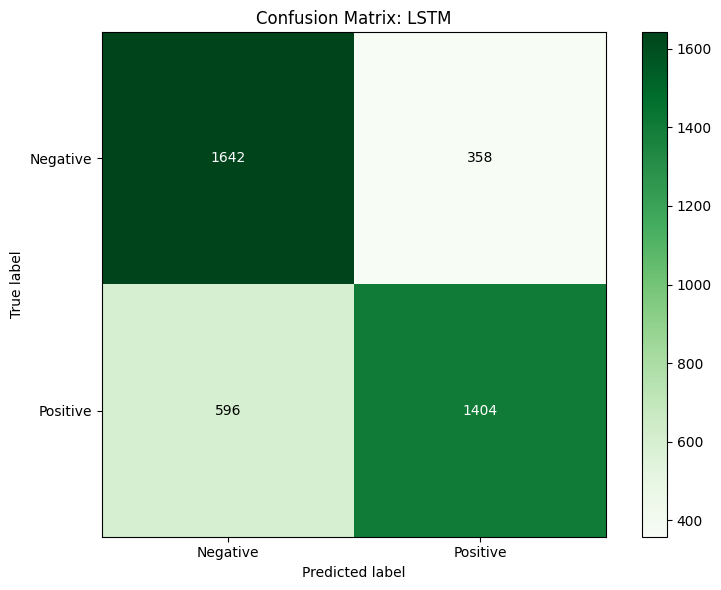

In [16]:
# Confusion Matrix for LSTM
cm_lstm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(8, 6))
plt.imshow(cm_lstm, interpolation='nearest', cmap=plt.cm.Greens)
plt.title('Confusion Matrix: LSTM')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Negative', 'Positive'])
plt.yticks(tick_marks, ['Negative', 'Positive'])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_lstm[i, j],
                ha="center", va="center",
                color="white" if cm_lstm[i, j] > cm_lstm.max() / 2 else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

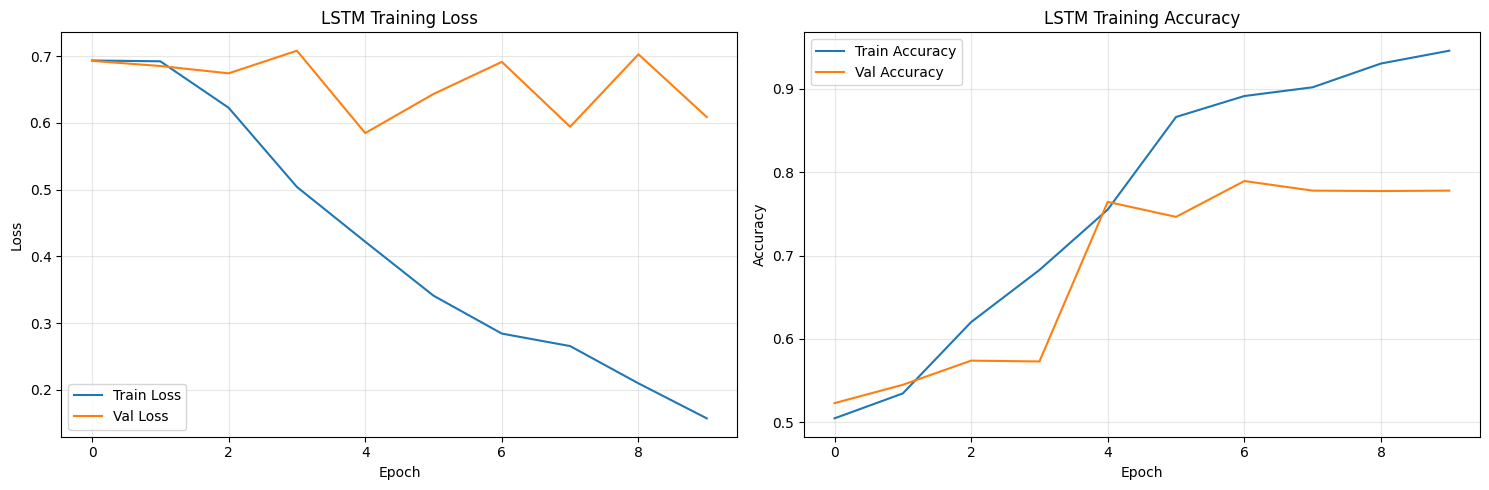

In [17]:
# Plot LSTM training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('LSTM Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('LSTM Training Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Comprehensive Comparison

In [18]:
# Performance comparison table
comparison_data = {
    'Metric': ['Accuracy', 'F1 Score', 'Preprocessing Time (s)', 'Training Time (s)', 'Prediction Time (s)', 'Total Time (s)'],
    'TF-IDF + LR': [
        f"{lr_accuracy:.4f}",
        f"{lr_f1:.4f}",
        f"{tfidf_time:.2f}",
        f"{lr_train_time:.2f}",
        f"{lr_pred_time:.2f}",
        f"{tfidf_time + lr_train_time + lr_pred_time:.2f}"
    ],
    'LSTM': [
        f"{lstm_accuracy:.4f}",
        f"{lstm_f1:.4f}",
        f"{lstm_prep_time:.2f}",
        f"{lstm_train_time:.2f}",
        f"{lstm_pred_time:.2f}",
        f"{lstm_prep_time + lstm_train_time + lstm_pred_time:.2f}"
    ]
}

print("\n" + "=" * 70)
print("PERFORMANCE COMPARISON")
print("=" * 70)
print(f"{'Metric':<25s} {'TF-IDF + LR':<20s} {'LSTM':<20s}")
print("-" * 70)
for i in range(len(comparison_data['Metric'])):
    print(f"{comparison_data['Metric'][i]:<25s} {comparison_data['TF-IDF + LR'][i]:<20s} {comparison_data['LSTM'][i]:<20s}")
print("=" * 70)


PERFORMANCE COMPARISON
Metric                    TF-IDF + LR          LSTM                
----------------------------------------------------------------------
Accuracy                  0.8720               0.7615              
F1 Score                  0.8729               0.7464              
Preprocessing Time (s)    5.76                 3.09                
Training Time (s)         0.13                 31.97               
Prediction Time (s)       0.00                 1.19                
Total Time (s)            5.90                 36.25               


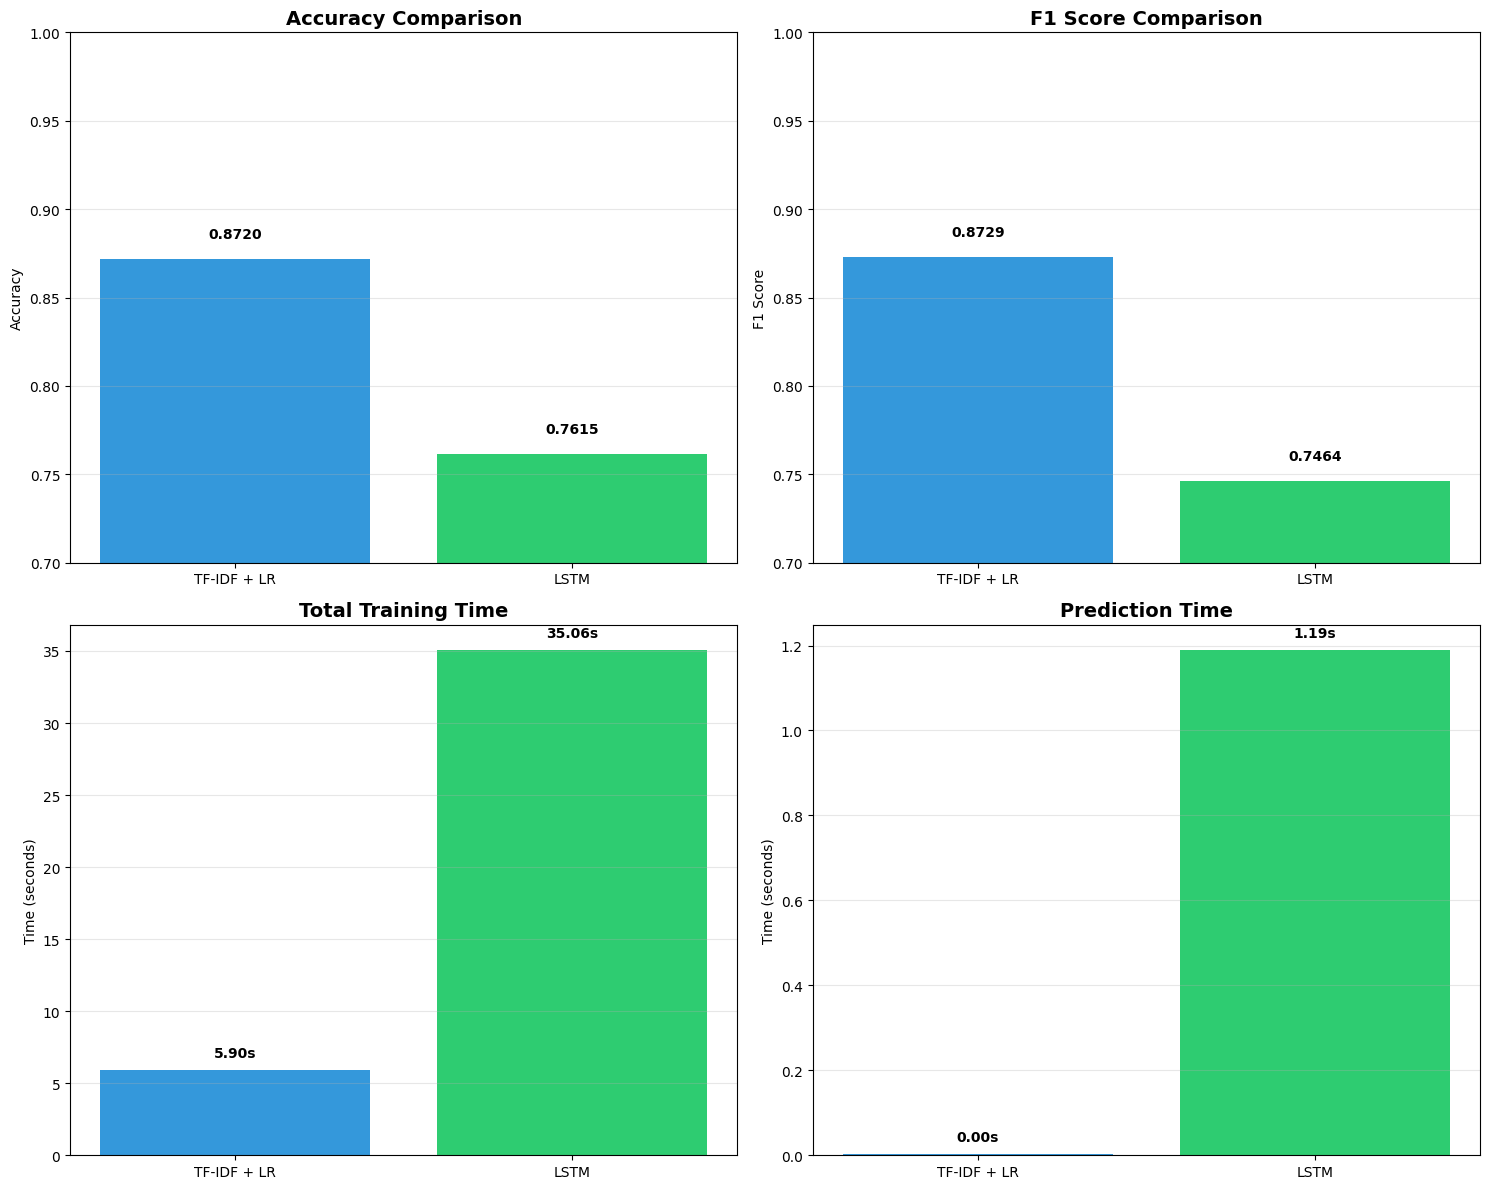

In [19]:
# Visual comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Accuracy comparison
models = ['TF-IDF + LR', 'LSTM']
accuracies = [lr_accuracy, lstm_accuracy]
colors = ['#3498db', '#2ecc71']

axes[0, 0].bar(models, accuracies, color=colors)
axes[0, 0].set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_ylim([0.7, 1.0])
for i, v in enumerate(accuracies):
    axes[0, 0].text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# F1 Score comparison
f1_scores = [lr_f1, lstm_f1]
axes[0, 1].bar(models, f1_scores, color=colors)
axes[0, 1].set_title('F1 Score Comparison', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('F1 Score')
axes[0, 1].set_ylim([0.7, 1.0])
for i, v in enumerate(f1_scores):
    axes[0, 1].text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Training time comparison
train_times = [tfidf_time + lr_train_time, lstm_prep_time + lstm_train_time]
axes[1, 0].bar(models, train_times, color=colors)
axes[1, 0].set_title('Total Training Time', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Time (seconds)')
for i, v in enumerate(train_times):
    axes[1, 0].text(i, v + max(train_times)*0.02, f'{v:.2f}s', ha='center', va='bottom', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Prediction time comparison
pred_times = [lr_pred_time, lstm_pred_time]
axes[1, 1].bar(models, pred_times, color=colors)
axes[1, 1].set_title('Prediction Time', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Time (seconds)')
for i, v in enumerate(pred_times):
    axes[1, 1].text(i, v + max(pred_times)*0.02, f'{v:.2f}s', ha='center', va='bottom', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Test on Custom Examples

In [20]:
# Test on custom reviews
custom_reviews = [
    "This movie was absolutely fantastic! The acting was superb and the plot kept me engaged throughout.",
    "Terrible waste of time. Poor acting, boring story, would not recommend to anyone.",
    "An okay film with some good moments but overall quite forgettable.",
    "Masterpiece! One of the best films I've ever seen. Brilliant cinematography and directing.",
    "Complete disaster. The worst movie of the year. Save your money and time."
]

print("Testing on custom reviews:")
print("=" * 80)

# TF-IDF + LR predictions
custom_tfidf = tfidf_vectorizer.transform(custom_reviews)
lr_predictions = lr_model.predict(custom_tfidf)
lr_probs = lr_model.predict_proba(custom_tfidf)[:, 1]

# LSTM predictions
custom_seq = tokenizer.texts_to_sequences(custom_reviews)
custom_pad = pad_sequences(custom_seq, maxlen=max_length, padding='post', truncating='post')
lstm_probs = lstm_model.predict(custom_pad, verbose=0).flatten()
lstm_predictions = (lstm_probs > 0.5).astype(int)

for i, review in enumerate(custom_reviews):
    print(f"\nReview {i+1}: {review}")
    print(f"  TF-IDF + LR: {'Positive' if lr_predictions[i] == 1 else 'Negative'} (confidence: {lr_probs[i]:.4f})")
    print(f"  LSTM:        {'Positive' if lstm_predictions[i] == 1 else 'Negative'} (confidence: {lstm_probs[i]:.4f})")
    
    if lr_predictions[i] != lstm_predictions[i]:
        print(f"  ⚠️  Models disagree!")

Testing on custom reviews:

Review 1: This movie was absolutely fantastic! The acting was superb and the plot kept me engaged throughout.
  TF-IDF + LR: Positive (confidence: 0.6387)
  LSTM:        Positive (confidence: 0.7406)

Review 2: Terrible waste of time. Poor acting, boring story, would not recommend to anyone.
  TF-IDF + LR: Negative (confidence: 0.0049)
  LSTM:        Negative (confidence: 0.1051)

Review 3: An okay film with some good moments but overall quite forgettable.
  TF-IDF + LR: Positive (confidence: 0.6320)
  LSTM:        Positive (confidence: 0.6051)

Review 4: Masterpiece! One of the best films I've ever seen. Brilliant cinematography and directing.
  TF-IDF + LR: Positive (confidence: 0.9471)
  LSTM:        Positive (confidence: 0.8212)

Review 5: Complete disaster. The worst movie of the year. Save your money and time.
  TF-IDF + LR: Negative (confidence: 0.0442)
  LSTM:        Negative (confidence: 0.1618)


## Key Findings and Conclusions

### TF-IDF + Logistic Regression
**Pros:**
- Fast training (seconds)
- Fast predictions
- Interpretable (can see important features)
- Lower memory requirements
- Works well with smaller datasets
- No GPU required

**Cons:**
- Loses word order information
- Can't capture complex patterns
- May struggle with nuanced language
- Fixed vocabulary limitations

### LSTM Deep Learning
**Pros:**
- Captures sequential information
- Can learn complex patterns
- Better at understanding context
- Generally higher accuracy on large datasets
- Can handle variable-length inputs better

**Cons:**
- Slower to train (minutes to hours)
- Requires more data for optimal performance
- Less interpretable (black box)
- Higher computational cost
- Benefits from GPU acceleration

### When to Use Each?

**Use TF-IDF + Logistic Regression when:**
- You need quick results
- Dataset is small to medium sized
- Interpretability is important
- Limited computational resources
- Need to explain predictions

**Use LSTM when:**
- You have large amounts of data
- Word order and context matter
- Maximum accuracy is critical
- Have access to GPU resources
- Longer training time is acceptable

### Conclusion
Both approaches have their place in NLP. Classical ML methods like TF-IDF + LR offer speed and interpretability, while deep learning methods like LSTM provide higher accuracy at the cost of complexity and computational resources. The choice depends on your specific requirements, dataset size, and available resources.